# Lag-CRP

> Quantify the tendency to recall items studied in nearby positions.

The lag-conditional response probability (Lag-CRP) measures how the probability of recalling an item depends on its serial lag from the previously recalled item. Serial lag is the difference in study positions: if the previous recall was studied at position $X$ and the current recall at position $Y$, then lag $\ell = Y - X$. Negative lags indicate backward transitions; positive lags indicate forward transitions.

$$\text{CRP}(\ell) = \frac{\text{actual transitions at lag } \ell}{\text{available transitions at lag } \ell}$$

At each recall step after the first, the set of available lags is determined by which study positions have not yet been recalled. The measure aggregates actual and available transition counts across trials before computing the ratio.

## Workflow

In [1]:
import os
import matplotlib.pyplot as plt
import warnings
from jaxcmr.analyses.crp import plot_crp
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure

warnings.filterwarnings("ignore")

In [2]:
data_path = "data/HealeyKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['listtype'] == -1"
max_lag = 5
size = 3
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

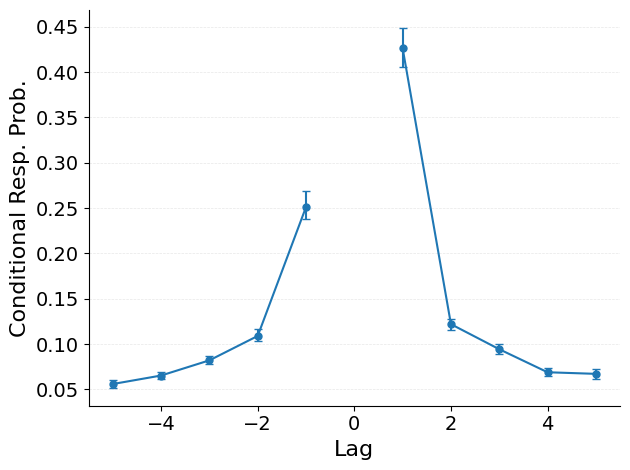

In [4]:
plot_crp(data, trial_mask, max_lag=max_lag, size=size, confidence_level=confidence_level)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

## Interpretation

The x-axis shows serial lag and the y-axis shows the conditional probability of making a transition at that lag. Key patterns to look for:

- **Contiguity effect**: peaks near lags $\pm 1$ indicate a tendency to recall items studied in nearby positions.
- **Forward asymmetry**: higher probabilities at positive lags than corresponding negative lags reflect a bias toward forward-order transitions.
- **Flat curve**: roughly uniform probabilities across lags suggest weak temporal organization in recall.

## API Details

### Notebook parameters

- `data_path` — path to an HDF5 file containing a `RecallDataset`.
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for the saved figure. Leave empty to display without saving.
- `ylim` — y-axis limits as a tuple, or `None` for automatic scaling.
- `trial_query` — a Python expression evaluated against the dataset to select trials.
- `max_lag` — maximum lag to display on the x-axis.
- `size` — maximum number of study positions a single item can occupy. Use 1 for lists with no repeated items.
- `confidence_level` — confidence level for subject-wise error bars.

To compare conditions, pass multiple datasets and masks directly to `plot_crp`:

```python
plot_crp([data, data], [mask_a, mask_b], labels=["Condition A", "Condition B"])
```

For lists with no repeated items, `simple_crp` provides a lighter-weight alternative that operates on serial-position-coded recall arrays.